# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN+LSTM architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [1]:
import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

# Dataset Selection

In [2]:
data_directory = "/media/anshu/New Volume/Dataset"

wav_files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

files = wav_files 

print("WAV:", len(wav_files))

WAV: 2452


In [3]:
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

## 1.1 Dataset Emotion Distribution

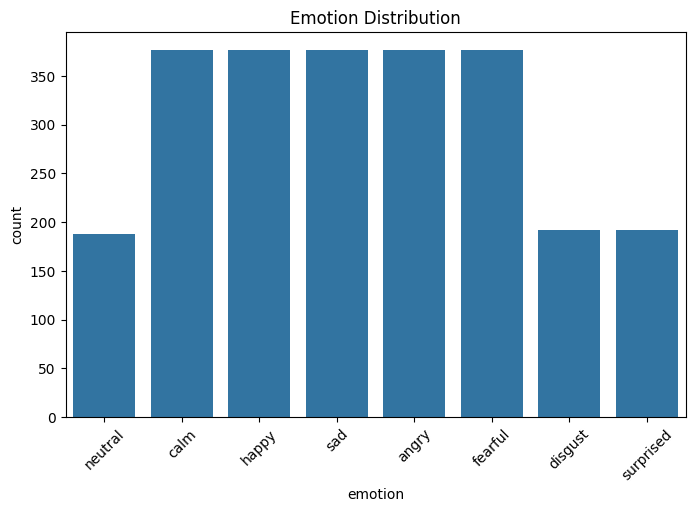

In [4]:
emotion_list = []

for file in wav_files:   
    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    emotion = emotion_map_number.get(emotion_code, "unknown")

    emotion_list.append(emotion)

# DataFrame
df = pd.DataFrame(emotion_list, columns=["emotion"])

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

# 1.2 Waveform Visualization

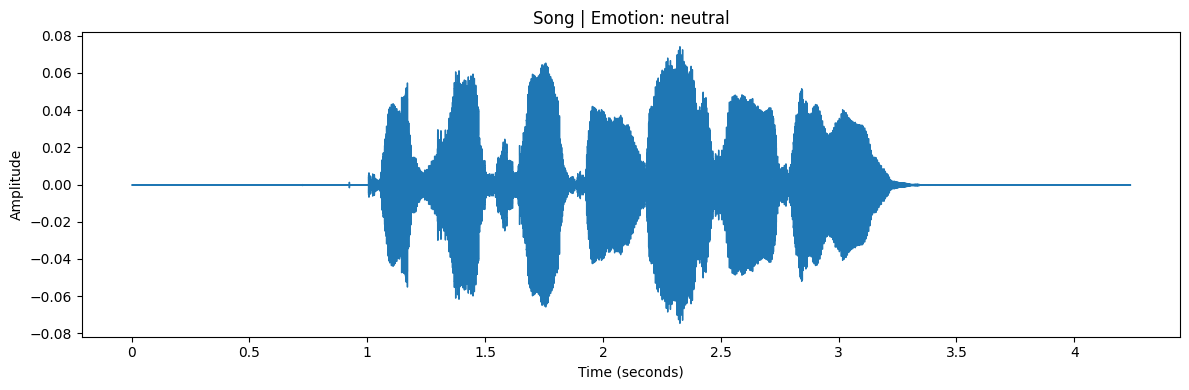

In [5]:
# ✅ Pick one file safely
file = wav_files[0]

data, sr = librosa.load(file, sr=22050)

# ---------- EXTRACT INFO ----------
file_name = os.path.basename(file)
parts = file_name.split("-")

emotion_code = parts[2] if len(parts) > 2 else "unknown"
emotion = emotion_map_number.get(emotion_code, "unknown")

dataset_type = "Speech" if "Speech" in file else "Song"

# ---------- PLOT ----------
plt.figure(figsize=(12,4))
librosa.display.waveshow(data, sr=sr)

plt.title(f"{dataset_type} | Emotion: {emotion}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

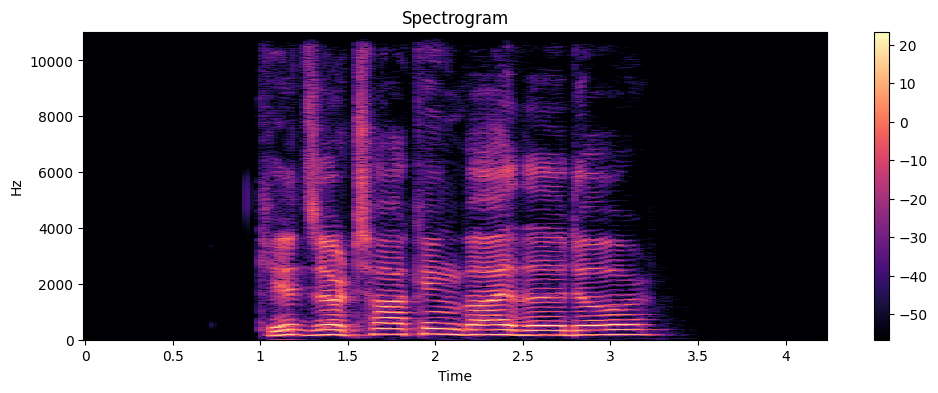

In [6]:
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")

# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

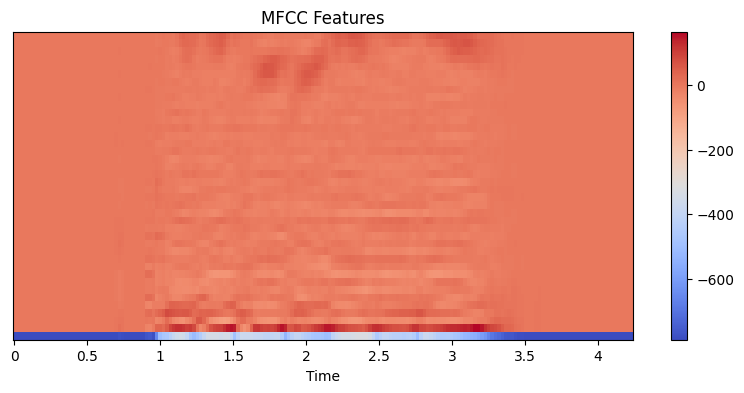

In [7]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")

# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [8]:
def extract_feature(data, sr, max_len=200):

    # ---------- EXTRACT FEATURES (NO MEAN) ----------
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # ---------- MATCH LENGTH ----------
    min_len = min(
        len(mfcc),
        len(chroma),
        len(mel),
        len(contrast),
        len(tonnetz),
        len(zcr),
        len(rms)
    )

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # ---------- CONCAT ----------
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # ---------- PAD / TRUNCATE ----------
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features

# 1.5 Feature Correlation Heatmap

In [9]:
import glob
import os
import numpy as np
import librosa

sample_features = []

files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

for f in files[:50]:
    try:
        data, sr = librosa.load(f, sr=22050)
        feat = extract_feature(data, sr)

        # ✅ ensure correct shape
        if feat.shape[0] == 200:
            sample_features.append(feat)
        else:
            print("Skipped (shape issue):", f)

    except Exception as e:
        print("Skipped:", f, "| Error:", e)

# ✅ convert to numpy
sample_features = np.array(sample_features)

print("Sample shape:", sample_features.shape)

Total files: 2452
Sample shape: (50, 200, 195)


# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [10]:
emotion_map = {
    'angry': 0,
    'calm': 1,
    'disgust': 2,
    'fearful': 3,
    'happy': 4,
    'neutral': 5,
    'sad': 6,
    'surprised': 7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(len(emotion_map))  # safer

    # ✅ always assign primary
    label[emotion_map[primary]] = w1 if secondary else 1.0

    # ✅ assign secondary only if exists
    if secondary:
        label[emotion_map[secondary]] = w2

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [11]:
np.random.seed(42)

In [12]:
import glob
import os
import numpy as np
import librosa
from tensorflow.keras.utils import to_categorical

X, y = [], []

# ✅ Load all files
files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

for file in files:

    try:
        data, sr = librosa.load(file, sr=22050)
    except:
        continue

    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    primary_emotion = emotion_map_number.get(emotion_code, None)

    if primary_emotion is None:
        continue

    # -------- FEATURE EXTRACTION --------
    feature = extract_feature(data, sr)

    # ✅ ensure correct shape (VERY IMPORTANT)
    if feature.shape[0] != 200:
        continue

    X.append(feature)

    # ✅ one-hot label (BEST for your case)
    label = to_categorical(emotion_map[primary_emotion], num_classes=8)
    y.append(label)

# ✅ Convert to numpy
X = np.array(X)
y = np.array(y)

print("\nDataset size:", X.shape)
print("Labels shape :", y.shape)

# ✅ NORMALIZATION (VERY IMPORTANT 🔥)
mean = np.mean(X, axis=(0,1), keepdims=True)
std  = np.std(X, axis=(0,1), keepdims=True)

X = (X - mean) / (std + 1e-6)

print("Normalized X shape:", X.shape)

I0000 00:00:1774690532.057052   38956 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774690532.057451   38956 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774690532.086932   38956 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774690533.444643   38956 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Total files: 2452


/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1012
  warnings.warn(



Dataset size: (2452, 200, 195)
Labels shape : (2452, 8)
Normalized X shape: (2452, 200, 195)


# Saving the Features

In [13]:
import pickle

# ✅ save normalization values
with open("normalization.pkl", "wb") as f:
    pickle.dump({
        "mean": mean,
        "std": std
    }, f)

# ✅ save emotion map
with open("emotion_map.pkl", "wb") as f:
    pickle.dump(emotion_map, f)

# Data Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)

# Reshaping the Data

In [15]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,              # 🔥 slightly higher for deep model
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # 🔥 smoother reduction
    patience=7,               # 🔥 avoid too early drop
    min_lr=1e-6,
    verbose=1
)

# Model checkpoint

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",      # ✅ modern format
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.layers import LSTM, Input, Bidirectional
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

model = Sequential([
    Input(shape=(200,195)),

    # CNN (moderate power)
    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    # LSTM (slightly reduced)
    Bidirectional(LSTM(48, return_sequences=False)),

    # Dense (slightly bigger than yours)
    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(8, activation='softmax')
])

E0000 00:00:1774691222.791231   38956 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774691222.806402   38956 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [19]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.00015)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# ✅ fix shape
X_train = np.squeeze(X_train)
X_test  = np.squeeze(X_test)

print(X_train.shape)

# ✅ train
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16       ,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 198, 64)        │        37,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 99, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 97, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 97, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96)             │        67,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,672 (537.78 KB)

 Trainable params: 137,288 (536.28 KB)

 Non-trainable params: 384 (1.50 KB)

(1961, 200, 195)
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1581 - loss: 2.1573
Epoch 1: val_accuracy improved from None to 0.27088, saving model to best_model.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1892 - loss: 2.1048 - val_accuracy: 0.2709 - val_loss: 2.0314 - learning_rate: 1.5000e-04
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2625 - loss: 1.9934
Epoch 2: val_accuracy improved from 0.27088 to 0.30550, saving model to best_model.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2545 - loss: 1.9807 - val_accuracy: 0.3055 - val_loss: 1.9100 - learning_rate: 1.5000e-04
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2736 - loss: 1.9505
Epoch 3: val_accuracy did not improve from 0.30550
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2973 - loss: 1.9292 - val_accuracy: 0.3055 - val_loss: 1.8990 - learning_rate: 1.5000e-04
Epoch 4/100
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step -

# Model Save

In [20]:
model.save("final_model_cnn_lstm.keras")

# Evaluation Matrics

In [21]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Accuracy: 0.7270875763747454

Classification Report:

              precision    recall  f1-score   support

       angry       0.81      0.89      0.85        75
        calm       0.85      0.81      0.83        75
     disgust       0.65      0.72      0.68        39
     fearful       0.71      0.63      0.67        75
       happy       0.72      0.69      0.71        75
     neutral       0.83      0.63      0.72        38
         sad       0.61      0.69      0.65        75
   surprised       0.63      0.67      0.65        39

    accuracy                           0.73       491
   macro avg       0.73      0.72      0.72       491
weighted avg       0.73      0.73      0.73       491



# confusion matrix visual

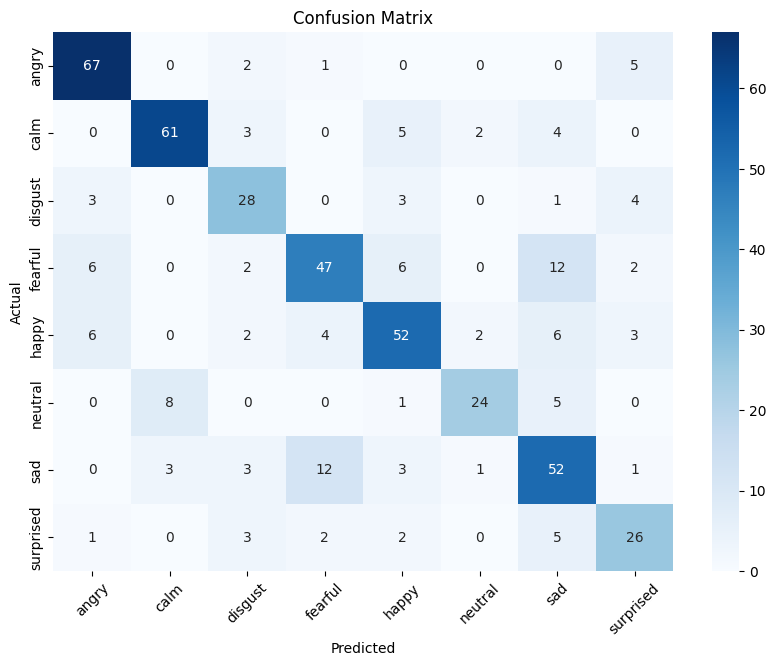

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.89333333 0.81333333 0.71794872 0.62666667 0.69333333 0.63157895
 0.69333333 0.66666667]
FPR: [0.03846154 0.02644231 0.03318584 0.04567308 0.04807692 0.01103753
 0.07932692 0.03318584]
TNR (Specificity): [0.96153846 0.97355769 0.96681416 0.95432692 0.95192308 0.98896247
 0.92067308 0.96681416]


In [24]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.7170242914979756
Mean FPR: 0.039423747280064675
Mean TNR: 0.9605762527199353


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.7313997512722016
Recall: 0.7270875763747454
F1 Score: 0.7268263631856757


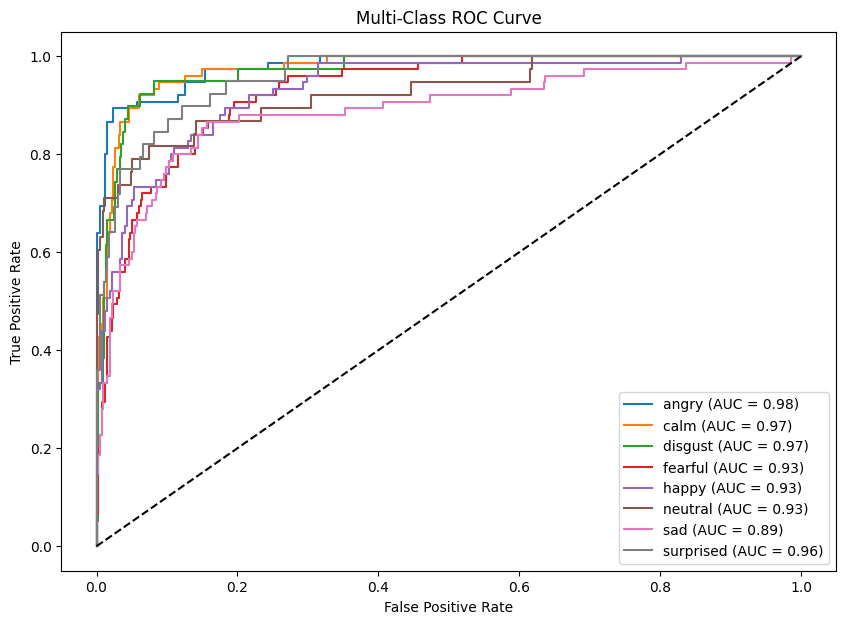

Average AUC: 0.9452755382865895


In [26]:
n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

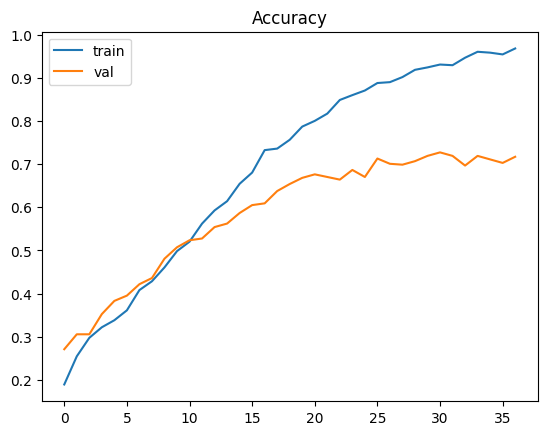

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

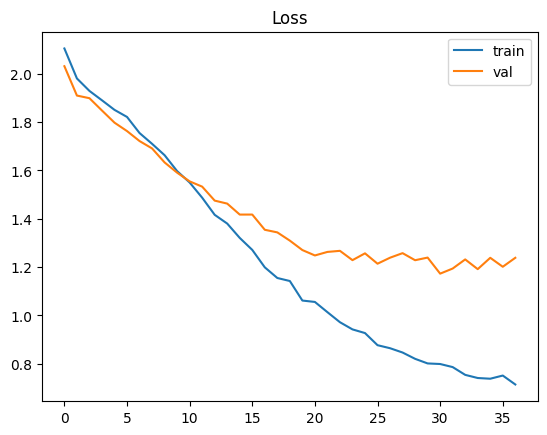

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [29]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn_lstm.keras")
loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7271 - loss: 1.1731
Loaded model accuracy: 0.7270875573158264


### Save new audio:

# Real-Time Emotion Detection

Record audio:

In [30]:
import sounddevice as sd

def record_audio(duration=3, sr=22050):

    print("Speak now")

    audio = sd.rec(int(duration*sr),
                   samplerate=sr,
                   channels=1)

    sd.wait()

    return audio.flatten()

# Predict emotion:

In [36]:
import pickle

with open("normalization.pkl", "rb") as f:
    scaler = pickle.load(f)
    

with open("emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

feature = scaler.transform(feature.reshape(1, -1))  
feature = np.expand_dims(feature, axis=2)


prediction = loaded_model.predict(feature)

inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)

EOFError: Ran out of input

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]
